In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
FEATURES_PATH = None
for cand in [
    Path("../../datasets/processed/features.csv"),
    Path("../datasets/processed/features.csv"),
    Path("datasets/processed/features.csv"),
]:
    if cand.exists():
        FEATURES_PATH = cand.resolve()
        break

if FEATURES_PATH is None:
    raise FileNotFoundError("features.csv not found.")

MODEL_DIR = Path("../../ml/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FILES = {
    "ridge": MODEL_DIR / "linear_model.pkl",
    "random_forest": MODEL_DIR / "random_forest_model.pkl",
    "xgboost": MODEL_DIR / "xgboost_model.pkl",
}

print(f"📂 Features: {FEATURES_PATH}")
print(f"📂 Models  : {MODEL_DIR}")
for k, p in MODEL_FILES.items():
    print(f"   {k:15s} exists={p.exists()}")

📂 Features: C:\Users\ASUS\OneDrive\Desktop\claude-test\smart-retail-intelligence-platform\datasets\processed\features.csv
📂 Models  : ..\..\ml\models
   ridge           exists=True
   random_forest   exists=True
   xgboost         exists=True


In [3]:
feat = pd.read_csv(FEATURES_PATH, low_memory=False)
feat["ds"] = pd.to_datetime(feat["ds"])
feat = feat.sort_values("ds").reset_index(drop=True)

def make_xy(df, cols):
    X = df[cols].copy()
    y = df["y"].astype(float).values
    X = X.fillna(X.median(numeric_only=True))
    return X, y

train = feat[feat["split"] == "train"].copy()
val   = feat[feat["split"] == "val"].copy()
test  = feat[feat["split"] == "test"].copy()

print("Split sizes:", feat["split"].value_counts().to_dict())

Split sizes: {'train': 736, 'test': 165, 'val': 164}


In [4]:
bundles = {}
for name, path in MODEL_FILES.items():
    if not path.exists():
        print(f"⚠️ Missing: {path} — skip {name}")
        continue
    with open(path, "rb") as f:
        bundles[name] = pickle.load(f)
    print(f"✅ Loaded {name} | type={bundles[name].get('model_type')} | features={len(bundles[name].get('feature_cols', []))}")

if not bundles:
    raise FileNotFoundError("No model pickles found. Run 04 and 05 first.")

✅ Loaded ridge | type=ridge | features=47
✅ Loaded random_forest | type=random_forest | features=47
✅ Loaded xgboost | type=xgboost | features=47


In [5]:
def metrics_dict(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape = float(np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), eps, None))) * 100)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "n": int(len(y_true))}

In [6]:
rows = []
predictions = {}  # name -> DataFrame with ds, y, yhat, split

for name, bundle in bundles.items():
    model = bundle["model"]
    cols = bundle["feature_cols"]

    # Align features (in case models were trained with slightly different sets)
    use_cols = [c for c in cols if c in feat.columns]
    if len(use_cols) != len(cols):
        missing = set(cols) - set(use_cols)
        print(f"⚠️ {name}: missing features {missing} — using {len(use_cols)} cols")

    split_metrics = {"model": name}
    pred_parts = []

    for split_name, df_s in [("train", train), ("val", val), ("test", test)]:
        if len(df_s) == 0:
            continue
        X_s, y_s = make_xy(df_s, use_cols)
        yhat = model.predict(X_s)
        m = metrics_dict(y_s, yhat)
        split_metrics[split_name] = m
        pred_parts.append(pd.DataFrame({
            "ds": df_s["ds"].values,
            "y": y_s,
            "yhat": yhat,
            "split": split_name,
            "model": name,
        }))

    predictions[name] = pd.concat(pred_parts, ignore_index=True)
    rows.append(split_metrics)

# Flat comparison table
flat = []
for r in rows:
    for split in ["train", "val", "test"]:
        if split in r:
            flat.append({
                "model": r["model"],
                "split": split,
                "MAE": r[split]["MAE"],
                "RMSE": r[split]["RMSE"],
                "MAPE": r[split]["MAPE"],
                "n": r[split]["n"],
            })

compare_long = pd.DataFrame(flat)
compare_val = (
    compare_long[compare_long["split"] == "val"]
    .sort_values("MAE")
    .reset_index(drop=True)
)
compare_test = (
    compare_long[compare_long["split"] == "test"]
    .sort_values("MAE")
    .reset_index(drop=True)
)

print("VALIDATION ranking (by MAE):")
display(compare_val)

print("\nTEST ranking (by MAE):")
display(compare_test)

print("\nFull metrics:")
display(compare_long.pivot(index="model", columns="split", values=["MAE", "RMSE", "MAPE"]))

VALIDATION ranking (by MAE):


,model,split,MAE,RMSE,MAPE,n
0,xgboost,val,"255,149.61","326,190.32",3.23,164
1,random_forest,val,"531,661.75","984,686.36",6.12,164
2,ridge,val,"784,095.97","1,044,059.47",9.44,164



TEST ranking (by MAE):


,model,split,MAE,RMSE,MAPE,n
0,ridge,test,"866,804.43","1,102,590.81",10.53,165
1,xgboost,test,"904,109.02","1,189,369.33",10.71,165
2,random_forest,test,"994,551.04","1,414,895.35",11.35,165



Full metrics:


MAE                               RMSE               \
split               test      train        val         test        train   
model                                                                      
random_forest 994,551.04 560,033.37 531,661.75 1,414,895.35   889,099.64   
ridge         866,804.43 848,623.69 784,095.97 1,102,590.81 1,107,003.56   
xgboost       904,109.02 284,493.11 255,149.61 1,189,369.33   360,159.96   

                            MAPE             
split                  val  test train  val  
model                                        
random_forest   984,686.36 11.35  6.57 6.12  
ridge         1,044,059.47 10.53 10.22 9.44  
xgboost         326,190.32 10.71  3.54 3.23

In [7]:
# Primary rule: lowest VAL MAE (honest selection without peeking at test)
# Fallback: lowest TEST MAE if no val rows
if len(compare_val):
    best_name = compare_val.iloc[0]["model"]
    selection_split = "val"
    selection_mae = float(compare_val.iloc[0]["MAE"])
else:
    best_name = compare_test.iloc[0]["model"]
    selection_split = "test"
    selection_mae = float(compare_test.iloc[0]["MAE"])

print("=" * 60)
print(f"🏆 BEST MODEL: {best_name.upper()}")
print(f"   Selected by lowest {selection_split.upper()} MAE = {selection_mae:,.2f}")
print("=" * 60)

# Show test metrics of winner (reporting only)
if len(compare_test):
    win_test = compare_test[compare_test["model"] == best_name]
    if len(win_test):
        print("Winner TEST metrics:")
        display(win_test)

🏆 BEST MODEL: XGBOOST
   Selected by lowest VAL MAE = 255,149.61
Winner TEST metrics:


,model,split,MAE,RMSE,MAPE,n
1,xgboost,test,"904,109.02","1,189,369.33",10.71,165


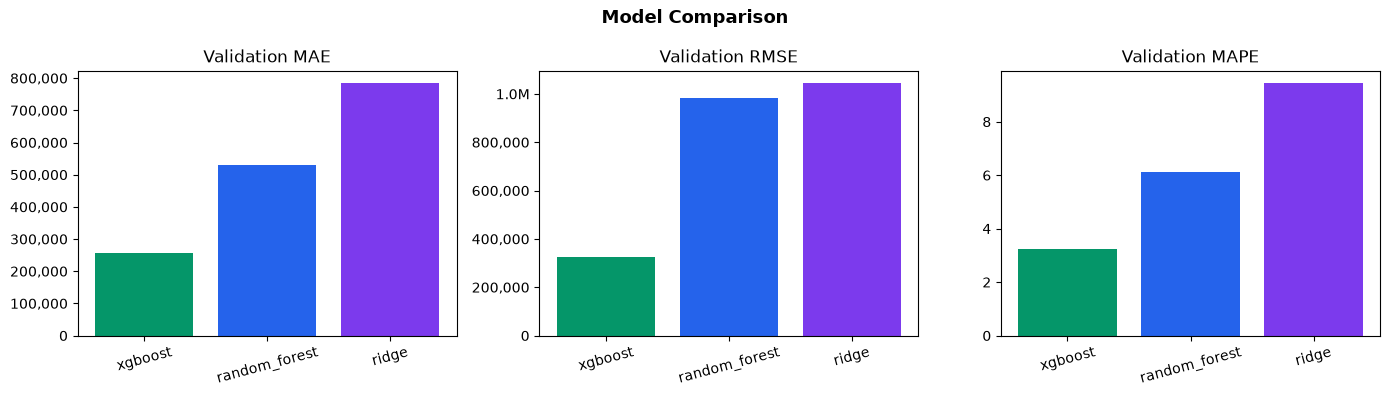

In [8]:
# VAL MAE / RMSE / MAPE side by side
plot_df = compare_val.copy() if len(compare_val) else compare_test.copy()
split_label = "Validation" if len(compare_val) else "Test"

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = {"ridge": "#7c3aed", "random_forest": "#2563eb", "xgboost": "#059669"}

for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE"]):
    vals = plot_df.set_index("model")[metric]
    bar_colors = [colors.get(m, "#64748b") for m in vals.index]
    ax.bar(vals.index, vals.values, color=bar_colors)
    ax.set_title(f"{split_label} {metric}")
    ax.tick_params(axis="x", rotation=15)
    if metric != "MAPE":
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x:,.0f}"))

plt.suptitle("Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

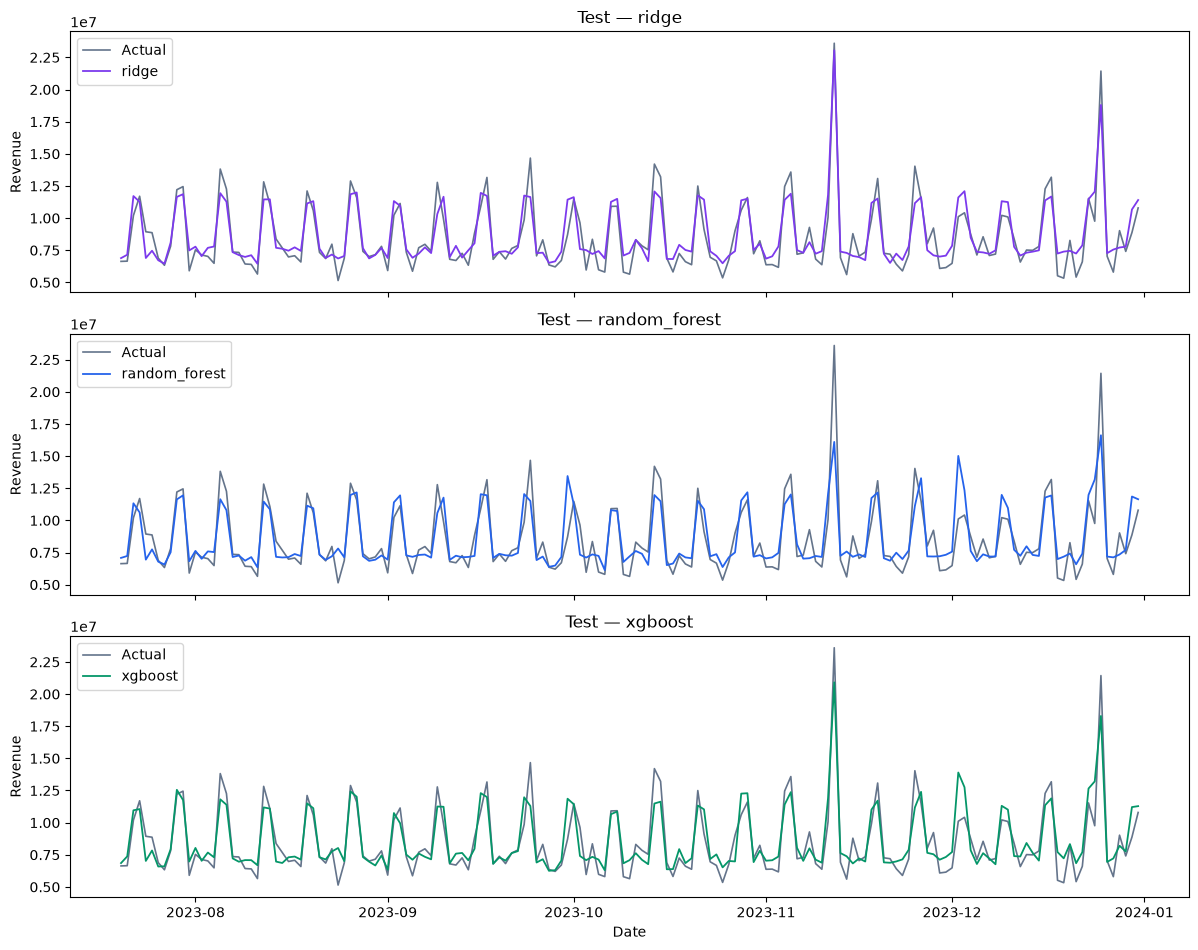

In [10]:
if len(test) == 0:
    print("No test rows — skip plot")
else:
    fig, axes = plt.subplots(len(predictions), 1, figsize=(12, 3.2 * len(predictions)), sharex=True)
    if len(predictions) == 1:
        axes = [axes]

    for ax, (name, pred_df) in zip(axes, predictions.items()):
        te = pred_df[pred_df["split"] == "test"]
        ax.plot(te["ds"], te["y"], color="#64748b", linewidth=1.2, label="Actual")
        ax.plot(te["ds"], te["yhat"], color=colors.get(name, "#059669"), linewidth=1.3, label=name)
        ax.set_ylabel("Revenue")
        ax.set_title(f"Test — {name}")
        ax.legend(loc="upper left")

    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()

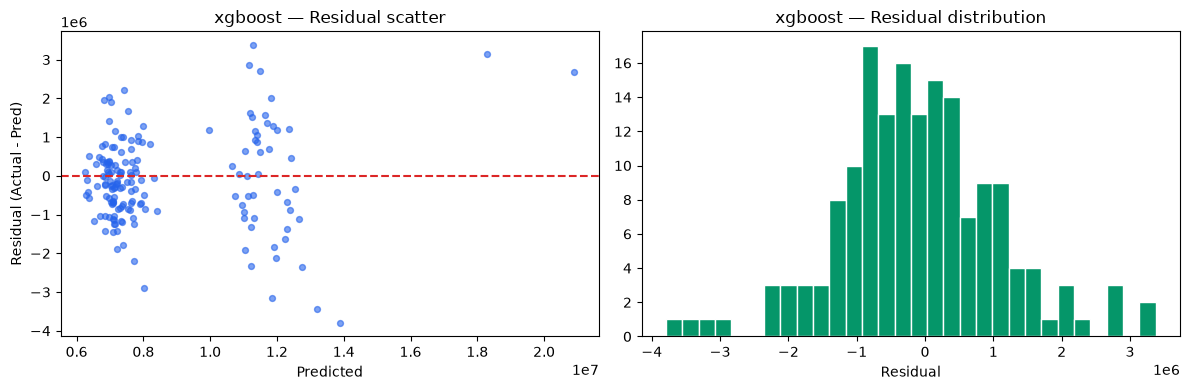

Residual mean: -105,408.25
Residual std : 1,188,295.57


In [11]:
win_pred = predictions[best_name]
win_test = win_pred[win_pred["split"] == "test"].copy()

if len(win_test) == 0:
    win_test = win_pred[win_pred["split"] == "val"].copy()
    print("Using VAL residuals (no test rows)")

win_test["residual"] = win_test["y"] - win_test["yhat"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(win_test["yhat"], win_test["residual"], alpha=0.6, color="#2563eb", s=18)
axes[0].axhline(0, color="#dc2626", linestyle="--")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual (Actual - Pred)")
axes[0].set_title(f"{best_name} — Residual scatter")

axes[1].hist(win_test["residual"], bins=30, color="#059669", edgecolor="white")
axes[1].set_title(f"{best_name} — Residual distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

print(f"Residual mean: {win_test['residual'].mean():,.2f}")
print(f"Residual std : {win_test['residual'].std():,.2f}")

In [12]:
# Copy winner bundle as best_model.pkl
best_bundle = dict(bundles[best_name])  # shallow copy
best_bundle["selected_as_best"] = True
best_bundle["selection_rule"] = f"lowest_{selection_split}_MAE"
best_bundle["selection_mae"] = selection_mae
best_bundle["compared_models"] = list(bundles.keys())

best_path = MODEL_DIR / "best_model.pkl"
with open(best_path, "wb") as f:
    pickle.dump(best_bundle, f)

# JSON report (no model object)
report = {
    "best_model": best_name,
    "selection_rule": f"lowest_{selection_split}_MAE",
    "selection_mae": selection_mae,
    "metrics_long": compare_long.to_dict(orient="records"),
    "val_ranking": compare_val.to_dict(orient="records") if len(compare_val) else [],
    "test_ranking": compare_test.to_dict(orient="records") if len(compare_test) else [],
    "model_files": {k: str(v) for k, v in MODEL_FILES.items() if v.exists()},
    "best_model_path": str(best_path),
}

report_path = MODEL_DIR / "model_comparison.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print(f"✅ Best model → {best_path}")
print(f"✅ Report     → {report_path}")
print(f"\nProduction model type: {best_bundle.get('model_type')}")
print(f"Feature count        : {len(best_bundle.get('feature_cols', []))}")

✅ Best model → ..\..\ml\models\best_model.pkl
✅ Report     → ..\..\ml\models\model_comparison.json

Production model type: xgboost
Feature count        : 47
